<!-- DE-STEP-HEADER -->
## 🧭 DE Pipeline Step 11/13 — หา HX ที่มีน้ำหนักต่อ CIT มากสุด (SHAP Importance)

**สถานะ:** ✅ ใช้งานจริง — `CHAIN[10]` ใน `pipeline/run_all.py`

**ตอบคำถามอะไร:** เอาโมเดลจาก step 10 มาหา SHAP importance — ย้ำว่าเป็น **ความสัมพันธ์ (attribution)
ไม่ใช่การพยากรณ์** (เพราะ step 10 บอกแล้วว่าโมเดลแพ้ baseline)

**มาจาก (Sources):** `priority_score` ใน `hx_Q_cleaning_priority_v2.csv` **ไม่ได้คำนวณใน notebook นี้**
— เป็น passthrough ของ `engineering_priority_score` จาก step 8's `Data/Engineering_Priority_Score.csv`
(โหลดตรง ๆ แล้ว assign เข้า `priority_v2['priority_score']`) notebook นี้เติมแค่คอลัมน์
`cit_shap_importance` (SHAP-based, จากโมเดล step 10) เป็นข้อมูลเสริม **ไม่ได้ blend กลับเข้าคะแนนหลัก**
(เคยลองแล้วพบว่าทำให้ ranking ผิด — ดู comment ในเซลล์คำนวณ) ดังนั้นทิศทางการอ้างอิงจริงคือ step 11 อ่านค่าจาก
step 8 ไม่ใช่ step 8 อ่านจาก step 11

**Input:** โมเดลจาก step 10, `Data/Engineering_Priority_Score.csv` (step 8)

**Output:** `hx_Q_cleaning_priority_v2.csv` → step 13 export เป็น `hx_ranking.json` (passthrough เดียวกัน)

**แดชบอร์ด:** กราฟ SHAP bar ranking (ถ้าเปิดดูใน notebook เอง — ไม่ได้ export เป็น dashboard panel แยก)

**Requirements ที่เกี่ยวข้อง:** สนับสนุน FR-PR-002 (Cleaning Prioritization — CIT-gain attribution)

---

# SHAP Importance Ranking — Which HX Drives CIT Most

Replaces the raw `feature_importances_`-based `cit_model_importance` column in
`outputs/hx_Q_cleaning_priority.csv` with a **SHAP**-based importance, using the
XGBoost/RandomForest models trained and saved by `10_cit_model_benchmark.ipynb`.

**Why XGBoost as the primary SHAP target:** `shap.TreeExplainer` is exact and fast
for tree ensembles. RandomForest is explained too as a cross-check that the ranking
isn't an XGBoost-specific artifact. LSTM is *not* explained with SHAP DeepExplainer
(known TF2/Keras3 compatibility issues, and unnecessary here — SHAP's role is
explaining the tree-based champion for the HX ranking); instead LSTM gets a
permutation-importance sanity check.

Sections:
1. Load feature matrix + saved model artifacts from `6a`
2. SHAP values — XGBoost (primary)
3. SHAP values — RandomForest (cross-check)
4. Per-HX aggregated SHAP importance + ranking plot
5. LSTM permutation importance (sanity check, not SHAP)
6. Rebuild `hx_Q_cleaning_priority_v2.csv` with SHAP-based `priority_score`

> ⚠️ **Read SHAP here as ASSOCIATIVE, not causal or predictive.** The tree CIT model this SHAP explains does **not beat a persistence baseline out-of-sample** (walk-forward CV, `6a`). SHAP still shows which HX features the model *leaned on* — useful for attribution and hypothesis-generation — but a high SHAP value is **not** evidence that cleaning that HX moves CIT by a validated amount. The cleaning ranking (`2d`) leans on measured Q-duty signals for this reason; SHAP here is a secondary lens.

## 0. Imports & Load Artifacts

In [1]:
import warnings, os, sys
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
from pathlib import Path
from sklearn.metrics import mean_absolute_error

sys.path.append(str(Path.cwd()))
from cpht_features import build_cit_feature_matrix, HX_CONFIG
from cpht_config import CPHT_1_HX

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

REPO_ROOT  = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization')
FIG_DIR    = REPO_ROOT / 'figures' / 'shap'
OUT_DIR    = REPO_ROOT / 'outputs'
MODELS_DIR = REPO_ROOT / 'models'
FIG_DIR.mkdir(parents=True, exist_ok=True)

xgb_model = joblib.load(MODELS_DIR / 'xgb_cit_model.joblib')
rf_model  = joblib.load(MODELS_DIR / 'rf_cit_model.joblib')
lstm_bundle = joblib.load(MODELS_DIR / 'lstm_scalers.joblib')
sx, sy, ENROL = lstm_bundle['scaler_X'], lstm_bundle['scaler_y'], lstm_bundle['enrol_window']

from tensorflow import keras
lstm_model = keras.models.load_model(MODELS_DIR / 'lstm_cit_model.keras')

print('Loaded XGBoost, RandomForest, and LSTM artifacts from', MODELS_DIR)

Loaded XGBoost, RandomForest, and LSTM artifacts from C:\Desktop\Bangchak Internship 2026\furnace-optimization\models


In [2]:
bundle = build_cit_feature_matrix()
X, y = bundle['X'], bundle['y']

# Same chronological 80/20 split as 6a — must match exactly for the loaded
# models' test set to be meaningful.
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Test set: {X_test.index.min().date()} -> {X_test.index.max().date()}  (n={len(X_test)})')

Test set: 2025-06-18 -> 2026-07-01  (n=379)


---
## 1. SHAP Values — XGBoost (primary)

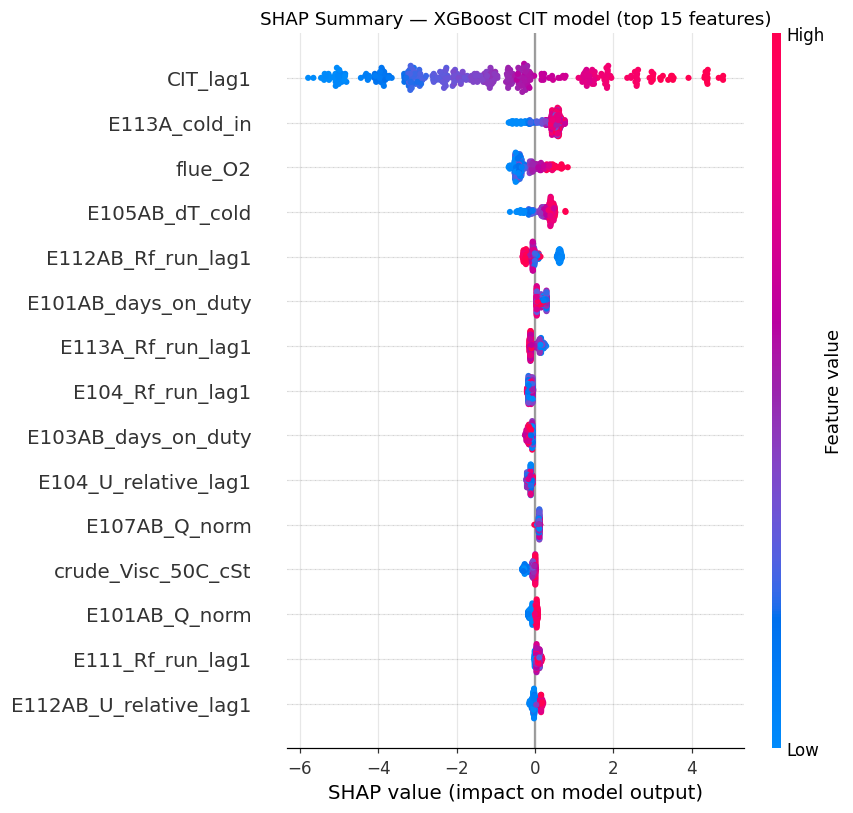

In [3]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, show=False, max_display=15)
plt.title('SHAP Summary — XGBoost CIT model (top 15 features)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary_xgboost.png', dpi=110, bbox_inches='tight')
plt.show()

## 2. SHAP Values — RandomForest (cross-check)

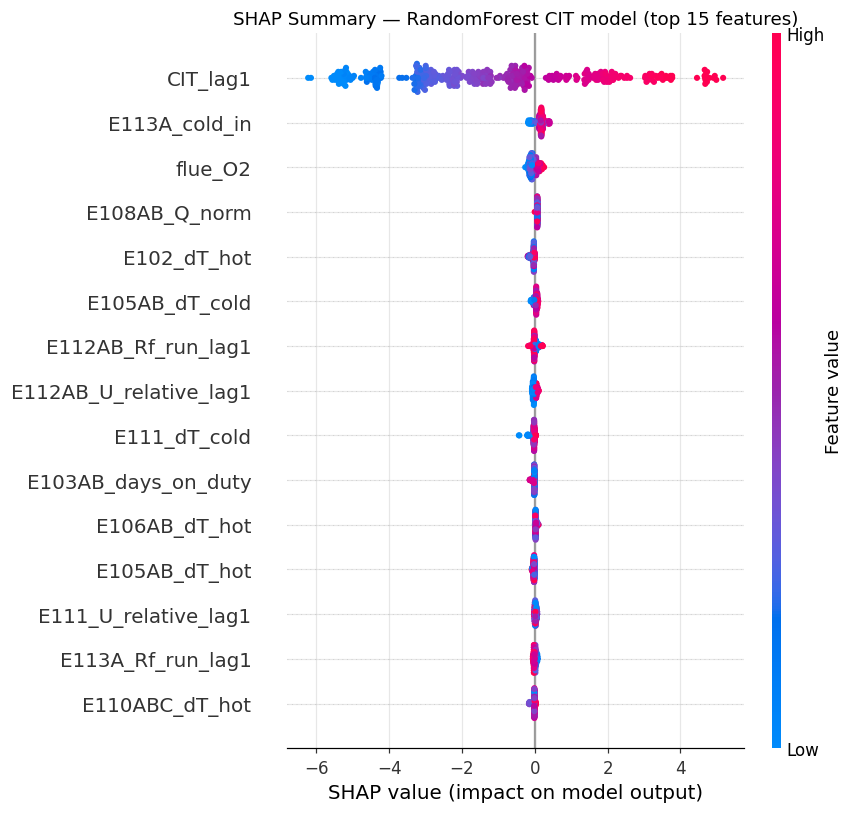

In [4]:
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

shap.summary_plot(shap_values_rf, X_test, show=False, max_display=15)
plt.title('SHAP Summary — RandomForest CIT model (top 15 features)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary_randomforest.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 3. Per-HX Aggregated SHAP Importance

Per-HX importance = sum of `mean(|SHAP value|)` across that HX's engineered
feature columns (`_Q_norm`, `_dT_cold`, `_duty_kW`, `_dT_hot`) — mirrors the
aggregation pattern already used for `cit_model_importance` in
`09_cit_model_feature_matrix.ipynb` section 10, just swapping the importance source.

In [5]:
def aggregate_shap_per_hx(shap_values, feature_names, hx_list):
    mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
    hx_importance = {}
    for hx in hx_list:
        cols = [c for c in feature_names if c.startswith(hx + '_')]
        if cols:
            hx_importance[hx] = mean_abs_shap[cols].sum()
    return pd.Series(hx_importance).sort_values(ascending=False)

hx_list = list(HX_CONFIG.keys())
shap_hx_xgb = aggregate_shap_per_hx(shap_values_xgb, X.columns, hx_list)
shap_hx_rf  = aggregate_shap_per_hx(shap_values_rf,  X.columns, hx_list)

comparison = pd.DataFrame({'XGBoost_SHAP': shap_hx_xgb, 'RandomForest_SHAP': shap_hx_rf}).fillna(0)
comparison['rank_corr'] = comparison['XGBoost_SHAP'].rank().corr(comparison['RandomForest_SHAP'].rank())
print(f"XGBoost vs RandomForest per-HX SHAP ranking Spearman-like agreement: "
      f"{comparison['XGBoost_SHAP'].rank().corr(comparison['RandomForest_SHAP'].rank(), method='spearman'):.3f}")
comparison.sort_values('XGBoost_SHAP', ascending=False).round(4)

XGBoost vs RandomForest per-HX SHAP ranking Spearman-like agreement: 0.506


,XGBoost_SHAP,RandomForest_SHAP,rank_corr
E113A,0.6583,0.2147,0.5059
E105AB,0.4096,0.0824,0.5059
E112AB,0.3705,0.1209,0.5059
E104,0.2937,0.0621,0.5059
E101AB,0.2889,0.0271,0.5059
E111,0.2159,0.1068,0.5059
E107AB,0.1929,0.0767,0.5059
E103AB,0.1672,0.0657,0.5059
E110ABC,0.1622,0.0683,0.5059
E109AB,0.1133,0.0433,0.5059


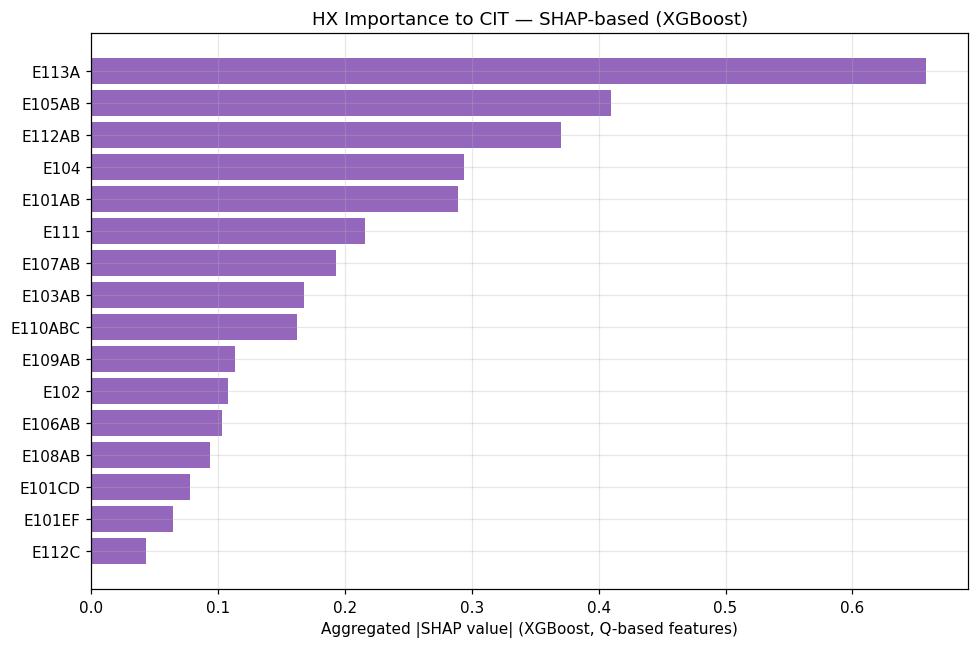

E113A      0.658303
E105AB     0.409588
E112AB     0.370524
E104       0.293661
E101AB     0.288868
E111       0.215920
E107AB     0.192894
E103AB     0.167242
E110ABC    0.162193
E109AB     0.113320
E102       0.107365
E106AB     0.103041
E108AB     0.093632
E101CD     0.077664
E101EF     0.064525
E112C      0.043413
dtype: float32

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
order = shap_hx_xgb.sort_values(ascending=True).index
ax.barh(order, shap_hx_xgb.loc[order], color='tab:purple')
ax.set_xlabel('Aggregated |SHAP value| (XGBoost, Q-based features)')
ax.set_title('HX Importance to CIT — SHAP-based (XGBoost)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_hx_importance_ranking.png', dpi=110, bbox_inches='tight')
plt.show()

shap_hx_xgb.sort_values(ascending=False)

---
## 4. LSTM Permutation Importance (sanity check)

Not SHAP (DeepExplainer has known TF2/Keras3 compatibility issues and isn't
needed here — LSTM's role in the benchmark is to confirm a sequence model
doesn't beat the tree-based champion, not to drive the HX ranking). Instead:
shuffle each feature across the windowed test set and measure the increase in
MAE — a model-agnostic importance measure that works for any architecture.

In [7]:
Xte_s = sx.transform(X_test)
yte_s = sy.transform(y_test.values.reshape(-1, 1)).flatten()

def make_windows(arr, tgt, window):
    Xw, yw = [], []
    for i in range(window, len(arr)):
        Xw.append(arr[i - window:i])
        yw.append(tgt[i])
    return np.array(Xw), np.array(yw)

Xte_w, yte_w = make_windows(Xte_s, yte_s, ENROL)

baseline_pred = lstm_model.predict(Xte_w, verbose=0).flatten()
baseline_mae  = mean_absolute_error(yte_w, baseline_pred)

rng = np.random.default_rng(42)
perm_importance = {}
for j, feat_name in enumerate(X.columns):
    Xte_perm = Xte_w.copy()
    perm_idx = rng.permutation(Xte_perm.shape[0])
    Xte_perm[:, :, j] = Xte_perm[perm_idx, :, j]
    pred_perm = lstm_model.predict(Xte_perm, verbose=0).flatten()
    perm_importance[feat_name] = mean_absolute_error(yte_w, pred_perm) - baseline_mae

perm_importance_s = pd.Series(perm_importance).clip(lower=0)

lstm_hx_importance = {}
for hx in hx_list:
    cols = [c for c in X.columns if c.startswith(hx + '_')]
    if cols:
        lstm_hx_importance[hx] = perm_importance_s[cols].sum()
lstm_hx_importance_s = pd.Series(lstm_hx_importance).sort_values(ascending=False)

print(f'Baseline LSTM test MAE: {baseline_mae:.3f} °C')
lstm_hx_importance_s.round(4)

Baseline LSTM test MAE: 0.619 °C


E112C      0.0787
E112AB     0.0427
E109AB     0.0393
E111       0.0382
E106AB     0.0293
E110ABC    0.0276
E105AB     0.0250
E101EF     0.0210
E113A      0.0185
E101CD     0.0158
E103AB     0.0130
E107AB     0.0124
E108AB     0.0121
E104       0.0077
E101AB     0.0008
E102       0.0000
dtype: float64

In [8]:
rank_compare = pd.DataFrame({
    'XGBoost_SHAP_rank'      : shap_hx_xgb.rank(ascending=False),
    'LSTM_permutation_rank'  : lstm_hx_importance_s.reindex(shap_hx_xgb.index).rank(ascending=False),
}).sort_values('XGBoost_SHAP_rank')
agreement = rank_compare['XGBoost_SHAP_rank'].corr(rank_compare['LSTM_permutation_rank'], method='spearman')
print(f'XGBoost-SHAP vs LSTM-permutation rank agreement (Spearman): {agreement:.3f}')
rank_compare

XGBoost-SHAP vs LSTM-permutation rank agreement (Spearman): -0.103


,XGBoost_SHAP_rank,LSTM_permutation_rank
E113A,1.0,9.0
E105AB,2.0,7.0
E112AB,3.0,2.0
E104,4.0,14.0
E101AB,5.0,15.0
E111,6.0,4.0
E107AB,7.0,12.0
E103AB,8.0,11.0
E110ABC,9.0,6.0
E109AB,10.0,3.0


---
## 5. Rebuild Cleaning-Priority Table with SHAP-Based Importance

Loads the existing `outputs/hx_Q_cleaning_priority.csv` (built in
`09_cit_model_feature_matrix.ipynb`) and replaces `cit_model_importance` with the
SHAP-based `cit_shap_importance`, then recomputes `priority_score` with the
same equal-weight min-max formula:

`priority_score = (minmax(fouling_rate_abs) + minmax(cit_shap_importance) + minmax(Q_CIT_correlation)) / 3`

Only the importance source changes — `Q_fouling_rate_abs`, `Q_CIT_correlation`,
`recommended_action`, and `Q_drop_%` are reused as-is (already validated,
per the project's decision not to re-derive cleaning-event detection).

In [9]:
# --- Rebuild the cleaning-priority table on the sound engineering framework ---
# `hx_Q_cleaning_priority.csv` (v1) used a naive equal-weighted average of raw
# fouling rate / CIT importance / Q-CIT correlation, with no regard for
# cleaning effort, safety consequence, or fouling trajectory -- flagged as
# wrong (dominant real-world case: E113A undersold vs E101AB overstated,
# because raw Q-CIT correlation is negative for E113A due to a pinch effect,
# not lack of urgency -- see 2c/2d). The actually-reasoned ranking is
# `08_cleaning_priority_ranking.ipynb`'s Engineering Priority Score
# (Probability x Consequence / Effort, with safety weighting, trajectory,
# and -- as of this pass -- a direct CIT-gain override for the terminal
# E113A/E112C pair and a CPHT-1 indirect-effect discount). That framework is
# now the base; SHAP-based CIT importance is added as a *secondary,
# corroborating* signal (does it agree with which HX matters to CIT?), not
# blended equally back into the score -- that blending is exactly what broke
# the ranking before.
eng_priority = pd.read_csv(
    r'C:\Desktop\Bangchak Internship 2026\Data\Engineering_Priority_Score.csv',
    index_col='HX',
)
priority_v1 = pd.read_csv(OUT_DIR / 'hx_Q_cleaning_priority.csv', index_col=0)
print('Loaded engineering priority table:', eng_priority.shape)

hx_index = eng_priority.index
cit_shap_importance = shap_hx_xgb.reindex(hx_index).fillna(0)

# CPHT-1 units affect CIT only indirectly (via the desalter) -- their SHAP
# importance is informational cross-check only, flagged rather than trusted
# at face value, same caveat as the CIT-gain discount in 2d.
cpht1_flag = hx_index.isin(CPHT_1_HX) if 'CPHT_1_HX' in dir() else pd.Series(False, index=hx_index)

priority_v2 = pd.DataFrame(index=hx_index)
priority_v2['priority_score'] = eng_priority['engineering_priority_score']
priority_v2['probability_score'] = eng_priority['probability_score']
priority_v2['consequence_score'] = eng_priority['consequence_score']
priority_v2['effort_tier'] = eng_priority['effort_tier']
priority_v2['safety_flag'] = eng_priority['safety_flag']
priority_v2['worsening'] = eng_priority['worsening']
priority_v2['cit_shap_importance'] = cit_shap_importance
priority_v2['cit_shap_importance_indirect_cpht1'] = cpht1_flag
priority_v2['Q_fouling_rate_abs'] = eng_priority['fouling_rate_abs']
priority_v2['Q_CIT_correlation'] = eng_priority['Q_CIT_corr']
priority_v2['expected_CIT_gain_C'] = eng_priority['expected_CIT_gain_C']
priority_v2['recommended_action'] = priority_v1['recommended_action'].reindex(hx_index)
priority_v2['Q_drop_%'] = eng_priority['Q_drop_pct']

priority_v2 = priority_v2.sort_values('priority_score', ascending=False)

out_path = OUT_DIR / 'hx_Q_cleaning_priority_v2.csv'
priority_v2.to_csv(out_path)
print(f'Saved -> {out_path}')
priority_v2.round(4)


Loaded engineering priority table: (14, 35)
Saved -> C:\Desktop\Bangchak Internship 2026\furnace-optimization\outputs\hx_Q_cleaning_priority_v2.csv


,priority_score,probability_score,consequence_score,effort_tier,safety_flag,worsening,cit_shap_importance,cit_shap_importance_indirect_cpht1,Q_fouling_rate_abs,Q_CIT_correlation,expected_CIT_gain_C,recommended_action,Q_drop_%
HX,,,,,,,,,,,,,
E113A,1.0000,0.8571,1.0000,SWAP_CAPABLE,True,True,0.6583,False,5.3050,0.2191,7.5200,Clean now (past trigger),49.6
E112AB,0.9286,0.3571,0.7095,ONLINE_FULL,True,False,0.3705,False,1.0792,0.0003,0.0000,Stable / monitor,-10.7
E101AB,0.8571,1.0000,0.2190,ONLINE_FULL,False,True,0.2889,True,0.5320,0.2885,4.3601,Clean now (past trigger),40.0
E109AB,0.7857,0.5714,0.8143,TAM_ONLY,True,False,0.1133,False,3.4315,-0.3892,NaN,Clean now (past trigger),32.8
E104,0.7143,0.7857,0.2333,ONLINE_FULL,False,False,0.2937,False,0.3613,0.0929,1.8245,Clean now (past trigger),50.4
E108AB,0.6429,0.2143,0.7905,ONLINE_FULL,True,False,0.0936,False,0.0000,0.0633,0.2394,Clean now (past trigger),31.7
E110ABC,0.5714,0.1429,0.9476,ONLINE_FULL,True,False,0.1622,False,0.0000,0.2375,2.2432,Clean now (past trigger),65.2
E101CD,0.5000,0.7143,0.2095,ONLINE_PARTIAL,False,False,0.0777,True,0.4671,0.3327,5.6382,Stable / monitor,43.5
E102,0.4286,0.4286,0.1762,ONLINE_FULL,False,True,0.1074,True,0.2211,0.5333,9.1778,Clean now (past trigger),49.9


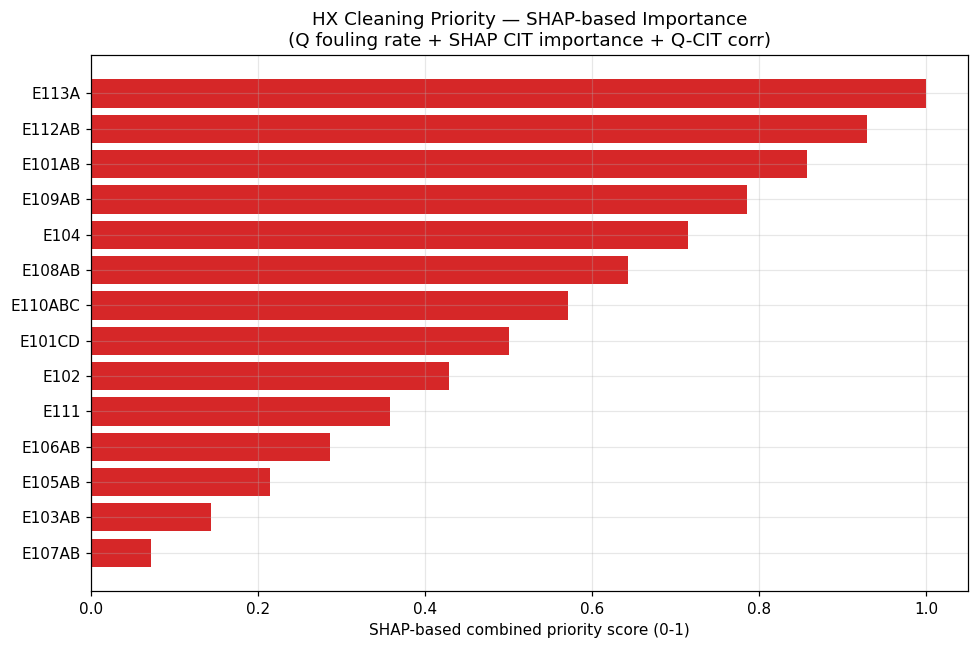

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
order = priority_v2.sort_values('priority_score').index
ax.barh(order, priority_v2.loc[order, 'priority_score'], color='tab:red')
ax.set_xlabel('SHAP-based combined priority score (0-1)')
ax.set_title('HX Cleaning Priority — SHAP-based Importance\n(Q fouling rate + SHAP CIT importance + Q-CIT corr)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hx_cleaning_priority_shap.png', dpi=110, bbox_inches='tight')
plt.show()

In [11]:
rank_shift = pd.DataFrame({
    'naive_v1_rank (equal-weight average)': priority_v1['priority_score'].rank(ascending=False).astype(int),
    'engineering_v2_rank (Probability x Consequence / Effort)': priority_v2['priority_score'].rank(ascending=False).astype(int),
}).sort_values('engineering_v2_rank (Probability x Consequence / Effort)')
rank_shift['rank_change'] = (
    rank_shift['naive_v1_rank (equal-weight average)']
    - rank_shift['engineering_v2_rank (Probability x Consequence / Effort)']
)
print('Ranking correction check -- naive equal-weighted v1 vs sound engineering v2:')
print('(largest positive rank_change = most underrated by the old naive score)')
rank_shift


Ranking correction check -- naive equal-weighted v1 vs sound engineering v2:
(largest positive rank_change = most underrated by the old naive score)


,naive_v1_rank (equal-weight average),engineering_v2_rank (Probability x Consequence / Effort),rank_change
E113A,1,1.0,0.0
E112AB,12,2.0,10.0
E101AB,4,3.0,1.0
E109AB,16,4.0,12.0
E104,10,5.0,5.0
E108AB,9,6.0,3.0
E110ABC,7,7.0,0.0
E101CD,6,8.0,-2.0
E102,8,9.0,-1.0
E111,14,10.0,4.0


---
## Summary

- `outputs/hx_Q_cleaning_priority_v2.csv` now ranks HX by a **SHAP-based**
  `cit_shap_importance` instead of raw `feature_importances_`.
- Cross-checked against RandomForest SHAP and LSTM permutation importance —
  see the rank-agreement figures above for how stable the ranking is across
  model choice.
- `13_cit_forecast_export.ipynb` consumes this v2 file to
  build the final cleaning-recommendation table and dashboard export.